# Running Generalised linear mixed effect model with R library 

First, for YN task and for 2AFC task we run GLMM and visualise with Average Marginal Effects (AME). Then the YN task is split into signal present and signal absent trials to run GLMM and plot (AME).

In [ ]:
#load the R library run it using python

In [3]:
%load_ext rpy2.ipython

In [ ]:
import pandas as pd

#specify the path to the behvioral accuracy file (merged eye tracking + behavioral data with group leave-one-out behavioral accuracy))
df = pd.read_csv(
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_group_LOO_behavioural_accuracy_30_subjects_final.csv"
)
df.head()


,participant_id,segment_num,pilot_mean,group_mean,correct_response_occlusion,correct_response,response_occlusion,final_choice,target_on_left,occluded_image,...,movie,sum_correct_2AFC,sum_correct_YN,n_participants,mean_correct_2AFC_LOO,mean_correct_YN_LOO,signal_present,sum_hits_SP,n_participants_SP,mean_correct_YN_LOO_signal_present
0,7,1,0.320988,0.345468,0,1,no_response,left,True,left,...,sprout,24,19,30,79.310345,65.517241,NaN,13.0,13,NaN
1,7,2,0.432613,0.567754,1,1,left,left,True,right,...,sprout,30,26,30,100.000000,86.206897,1.0,12.0,13,91.666667
2,7,3,-0.107644,0.678453,1,1,left,right,False,left,...,sprout,27,23,30,89.655172,75.862069,1.0,10.0,13,75.000000
3,7,4,-0.089511,0.208065,1,1,left,left,True,right,...,sprout,30,26,30,100.000000,86.206897,1.0,15.0,17,87.500000
4,7,5,0.535462,0.447035,1,1,right,right,False,right,...,sprout,29,23,30,96.551724,75.862069,NaN,13.0,17,NaN


In [ ]:
#getting 2AFC marginal effects after running GLMM (after decomposition)

In [8]:
%%R -i df
library(lme4)
library(marginaleffects)

# ----------------------------
# Create decomposition predictors
# ----------------------------
df$pilot_z <- as.numeric(scale(df$pilot_mean))
df$group_z <- as.numeric(scale(df$group_mean))

df$Z1 <- (df$pilot_z + df$group_z) / 2   # shared synchrony
df$Z2 <- (df$pilot_z - df$group_z) / 2   # individual deviation from group

# ----------------------------
# Fit GLMM (2AFC)
# ----------------------------
glmm_decomp_2afc <- glmer(
  correct_response ~
    Z1 +
    Z2 +
    mean_correct_2AFC_LOO +
    (1 | participant_id),
  data = df,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa")
)

summary(glmm_decomp_2afc)

# ----------------------------
# Average Marginal Effects (probability scale)
# ----------------------------
# type="response" => effects in ΔP (change in predicted probability)
ame_2afc <- avg_slopes(
  glmm_decomp_2afc,
  variables = c("Z1", "Z2", "mean_correct_2AFC_LOO"),
  type = "response"
)

ame_2afc



                  Term Estimate Std. Error      z Pr(>|z|)     S   2.5 %
 Z1                    -0.00408    0.00479 -0.851    0.395   1.3 -0.0135
 Z2                    -0.00957    0.01409 -0.679    0.497   1.0 -0.0372
 mean_correct_2AFC_LOO  0.00654    0.00028 23.404   <0.001 400.0  0.0060
  97.5 %
 0.00532
 0.01805
 0.00709

Type: response
Comparison: dY/dX



Loading required package: Matrix
Please cite the software developers who make your work possible.
One package:             citation("package_name")
All project packages:    softbib::softbib()

Attaching package: ‘marginaleffects’

The following object is masked from ‘package:lme4’:

    refit

In addition: Warning messages:
1: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?
2: For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


In [ ]:
##saving the results of 2AFC marginal effects after decomposition

In [115]:
%%R
ame_2afc_df <- as.data.frame(ame_2afc)


# Keep only what you need for plotting
ame_2afc_out <- data.frame(
  Predictor = ame_2afc_df$term,
  AME       = ame_2afc_df$estimate,
  CI_low    = ame_2afc_df$conf.low,
  CI_high   = ame_2afc_df$conf.high,
  SE        = ame_2afc_df$std.error,
  p_value   = ame_2afc_df$p.value
)

# Add the same labels you used before
label_map <- c(
  Z1 = "(individual sync + group sync)/2",
  Z2 = "(individual sync - group sync)/2",
mean_correct_2AFC_LOO = "mean_correct_2AFC_LOO"
)
ame_2afc_out$label <- unname(label_map[ame_2afc_out$Predictor])

OUT_PATH <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/2AFC_decomposition_AME_30_subjects.csv"
write.csv(ame_2afc_out, OUT_PATH, row.names = FALSE)

ame_2afc_out


              Predictor          AME       CI_low     CI_high           SE
1                    Z1 -0.004078990 -0.013475150 0.005317170 0.0047940474
2                    Z2 -0.009569411 -0.037190876 0.018052054 0.0140928431
3 mean_correct_2AFC_LOO  0.006542935  0.005995002 0.007090868 0.0002795629
        p_value                            label
1  3.948556e-01 (individual sync + group sync)/2
2  4.971212e-01 (individual sync - group sync)/2
3 3.876638e-121            mean_correct_2AFC_LOO


In [ ]:
#average marginal effect for YN task after decomposition

In [4]:
import pandas as pd

df = pd.read_csv(
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_group_LOO_behavioural_accuracy_30_subjects_final.csv"
)


In [5]:
%%R -i df
library(lme4)
library(marginaleffects)


# (Recompute Z1/Z2 if needed; safe to keep)
df$pilot_z <- as.numeric(scale(df$pilot_mean))
df$group_z <- as.numeric(scale(df$group_mean))
df$Z1 <- (df$pilot_z + df$group_z) / 2
df$Z2 <- (df$pilot_z - df$group_z) / 2

glmm_decomp_yn <- glmer(
  correct_response_occlusion ~
    Z1 +
    Z2 +
    mean_correct_YN_LOO +
    (1 | participant_id),
  data = df,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa")
)

ame_yn <- avg_slopes(glmm_decomp_yn, variables = c("Z1","Z2","mean_correct_YN_LOO"), type = "response")
ame_yn_df <- as.data.frame(ame_yn)

ame_yn_out <- data.frame(
  Predictor = ame_yn_df$term,
  AME       = ame_yn_df$estimate,
  CI_low    = ame_yn_df$conf.low,
  CI_high   = ame_yn_df$conf.high,
  SE        = ame_yn_df$std.error,
  p_value   = ame_yn_df$p.value
)


label_map <- c(
  Z1 = "(individual sync + group sync)/2",
  Z2 = "(individual sync - group sync)/2",
  mean_correct_YN_LOO = "mean_correct_YN_LOO"
)
ame_yn_out$label <- unname(label_map[ame_yn_out$Predictor])

OUT_PATH <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_decomposition_AME_30_subjects.csv"
write.csv(ame_yn_out, OUT_PATH, row.names = FALSE)

ame_yn_out


            Predictor         AME       CI_low     CI_high           SE
1                  Z1 0.004282528 -0.008035419 0.016600476 0.0062847827
2                  Z2 0.051654917  0.016464666 0.086845169 0.0179545399
3 mean_correct_YN_LOO 0.006938105  0.006231559 0.007644652 0.0003604896
       p_value                            label
1 4.956106e-01 (individual sync + group sync)/2
2 4.014964e-03 (individual sync - group sync)/2
3 1.514998e-82              mean_correct_YN_LOO


Loading required package: Matrix
Please cite the software developers who make your work possible.
One package:             citation("package_name")
All project packages:    softbib::softbib()

Attaching package: ‘marginaleffects’

The following object is masked from ‘package:lme4’:

    refit

In addition: Warning messages:
1: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model failed to converge with max|grad| = 0.00325985 (tol = 0.002, component 1)
  See ?lme4::convergence and ?lme4::troubleshooting.
2: In checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv,  :
  Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?
3: For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning

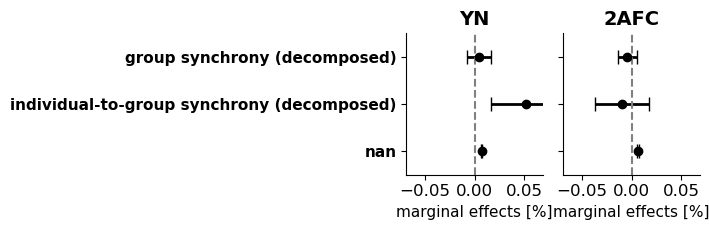

Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_2AFC_AME_forestplot.png


In [133]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------------------------
# Paths
# -------------------------------------------------
yn_path   = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_decomposition_AME_30_subjects.csv"
afc_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/2AFC_decomposition_AME_30_subjects.csv"

df_yn   = pd.read_csv(yn_path)
df_2afc = pd.read_csv(afc_path)

# -------------------------------------------------
# Label harmonization (match your OR figure)
# -------------------------------------------------
# If your saved files already contain these labels, this will just keep them consistent.
label_map = {
    "Z1": "group synchrony (decomposed)",
    "Z2": "individual-to-group synchrony (decomposed)"
}

# If your YN/2AFC AME files store Predictor as Z1/Z2, map to paper labels.
if "Predictor" in df_yn.columns:
    df_yn["label_plot"] = df_yn["Predictor"].map(label_map).fillna(df_yn.get("label", df_yn["Predictor"]))
else:
    df_yn["label_plot"] = df_yn["label"]

if "Predictor" in df_2afc.columns:
    df_2afc["label_plot"] = df_2afc["Predictor"].map(label_map).fillna(df_2afc.get("label", df_2afc["Predictor"]))
else:
    df_2afc["label_plot"] = df_2afc["label"]

# Ensure same ordering across panels
order = ["group synchrony (decomposed)", "individual-to-group synchrony (decomposed)"]

df_yn["label_plot"]   = pd.Categorical(df_yn["label_plot"], categories=order,ordered=True)
df_2afc["label_plot"] = pd.Categorical(df_2afc["label_plot"], categories=order, ordered=True)

df_yn   = df_yn.sort_values("label_plot").reset_index(drop=True)
df_2afc = df_2afc.sort_values("label_plot").reset_index(drop=True)



# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, (ax_yn, ax_2afc) = plt.subplots(
    1, 2, figsize=(7.2, 2.4), sharey=True
)

y_pos = np.arange(len(df_yn))

# ---- YN ----
ax_yn.errorbar(
    df_yn["AME"],
    y_pos,
    xerr=[df_yn["AME"] - df_yn["CI_low"],
          df_yn["CI_high"] - df_yn["AME"]],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_yn.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_yn.set_title("YN", fontsize=14, weight="bold")
ax_yn.set_xlabel("marginal effects [%]", fontsize=11)

# ---- 2AFC ----
ax_2afc.errorbar(
    df_2afc["AME"],
    y_pos,
    xerr=[df_2afc["AME"] - df_2afc["CI_low"],
          df_2afc["CI_high"] - df_2afc["AME"]],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_2afc.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_2afc.set_title("2AFC", fontsize=14, weight="bold")
ax_2afc.set_xlabel("marginal effects [%]", fontsize=11)


# ---- Shared Y axis labels ----
ax_yn.set_yticks(y_pos)
ax_yn.set_yticklabels(df_yn["label_plot"].astype(str).values, fontsize=11, fontweight="bold")
ax_yn.invert_yaxis()

# ---- Symmetric x-limits around zero (standard for AMEs) ----
xmin = min(-0.05, 0.06)
xmax = max(-0.05, 0.06)
m = max(abs(xmin), abs(xmax)) * 1.15

ax_yn.set_xlim(-m, m)
ax_2afc.set_xlim(-m, m)

# ---- Clean look ----
for ax in (ax_yn, ax_2afc):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)
    ax_yn.set_ylim(len(y_pos)- 0.5, - 0.5) # consistent y-limits
   

plt.tight_layout()

# Optional: save
out_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_2AFC_AME_forestplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", out_path)


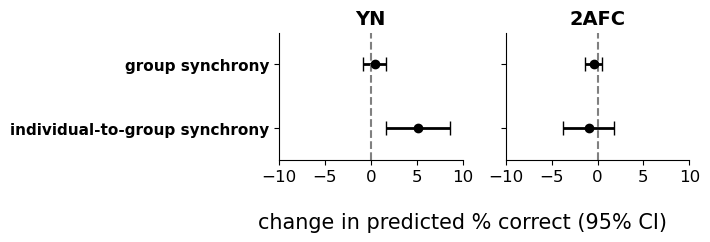

Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_2AFC_AME_forestplot.png


In [139]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import PercentFormatter

# -------------------------------------------------
# Paths
# -------------------------------------------------
yn_path   = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_decomposition_AME_30_subjects.csv"
afc_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/2AFC_decomposition_AME_30_subjects.csv"

df_yn   = pd.read_csv(yn_path)
df_2afc = pd.read_csv(afc_path)

df_yn = df_yn[df_yn["Predictor"].isin(["Z1", "Z2"])].copy()
df_2afc = df_2afc[df_2afc["Predictor"].isin(["Z1", "Z2"])].copy()
# -------------------------------------------------
# Label harmonization
# -------------------------------------------------
label_map = {
    "Z1": "group synchrony",
    "Z2": "individual-to-group synchrony"
}

if "Predictor" in df_yn.columns:
    df_yn["label_plot"] = df_yn["Predictor"].map(label_map).fillna(df_yn.get("label", df_yn["Predictor"]))
else:
    df_yn["label_plot"] = df_yn["label"]

if "Predictor" in df_2afc.columns:
    df_2afc["label_plot"] = df_2afc["Predictor"].map(label_map).fillna(df_2afc.get("label", df_2afc["Predictor"]))
else:
    df_2afc["label_plot"] = df_2afc["label"]

order = ["group synchrony", "individual-to-group synchrony"]

df_yn["label_plot"]   = pd.Categorical(df_yn["label_plot"], categories=order, ordered=True)
df_2afc["label_plot"] = pd.Categorical(df_2afc["label_plot"], categories=order, ordered=True)

df_yn   = df_yn.sort_values("label_plot").reset_index(drop=True)
df_2afc = df_2afc.sort_values("label_plot").reset_index(drop=True)

# -------------------------------------------------
# Plot
# -------------------------------------------------
fig, (ax_yn, ax_2afc) = plt.subplots(1, 2, figsize=(7.2, 2.4), sharey=True)

y_pos = np.arange(len(df_yn))

# Convert to percentage points
for df in (df_yn, df_2afc):
    df["AME_pp"] = df["AME"] *100
    df["CI_low_pp"] = df["CI_low"] *100
    df["CI_high_pp"] = df["CI_high"] *100

# ---- YN ----
ax_yn.errorbar(
    df_yn["AME_pp"],
    y_pos,
    xerr=[df_yn["AME_pp"] - df_yn["CI_low_pp"],
          df_yn["CI_high_pp"] - df_yn["AME_pp"]],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_yn.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_yn.set_title("YN", fontsize=14, weight="bold")


# ---- 2AFC ----

ax_2afc.errorbar(
    df_2afc["AME_pp"],
    y_pos,
    xerr=[df_2afc["AME_pp"] - df_2afc["CI_low_pp"],
          df_2afc["CI_high_pp"] - df_2afc["AME_pp"]],
    fmt="o",
    color="black",
    ecolor="black",
    elinewidth=2,
    capsize=5,
    markersize=6
)
ax_2afc.axvline(0, linestyle="--", color="gray", linewidth=1.5)
ax_2afc.set_title("2AFC", fontsize=14, weight="bold")


# ---- Shared Y axis labels ----
ax_yn.set_yticks(y_pos)
ax_yn.set_yticklabels(df_yn["label_plot"].astype(str).values, fontsize=11, fontweight="bold")
ax_yn.invert_yaxis()

# ---- Symmetric x-limits around zero ----
all_vals = np.concatenate([
    df_yn["CI_low_pp"].values, df_yn["CI_high_pp"].values,
    df_2afc["CI_low_pp"].values, df_2afc["CI_high_pp"].values
])

m = np.max(np.abs(all_vals)) * 1.15
for ax in (ax_yn, ax_2afc):
    ax.set_xticks(np.arange(-10, 11, 5))

# ---- Format x-axis as percentages ----
# AME values are probabilities, so 0.05 will display as 5%
for ax in (ax_yn, ax_2afc):
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=12)

ax_yn.set_ylim(len(y_pos) - 0.5, -0.5)

# title for x-axis

fig.supxlabel("change in predicted % correct (95% CI)", fontsize=15, x = 0.65)

plt.tight_layout()

out_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_2AFC_AME_forestplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")

plt.show()
print("Saved:", out_path)

In [ ]:
## for signal present and signal absent AMEs plotting

## For YN task: looking separately at signal present and signal absent trials

Obtaining one file for signal absent and one file for signal present trial, then doing GLMM and ploting AME

In [76]:
df = pd.read_csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present.csv")

In [ ]:
## script for gettig signal-absent trials (I alredy created a file with -aignal-absent trials so I do not need to run it again)

import pandas as pd
import numpy as np

# -------------------------------------------------------------
# 0. Load data
# -------------------------------------------------------------
input_path = (
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/"
    "sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/"
    "30_subjects_final/all_movies_merged_sync_behav_with_group_LOO_behavioural_accuracy_30_subjects_final.csv"
)

df = pd.read_csv(input_path)
df = df.copy()

print(f"Original data shape: {df.shape}")

# -------------------------------------------------------------
# 1. Identify SIGNAL-ABSENT trials (YN)
# -------------------------------------------------------------
# Signal absent = 1 → Correct Rejection (CR)
# Signal absent = 0 → False Alarm (FA)

df["signal_absent"] = np.where(
    (df["correct_response_occlusion"] == 1) & (df["response_occlusion"] == "right"), 1,
    np.where(
        (df["correct_response_occlusion"] == 0) & (df["response_occlusion"] == "left"), 0,
        np.nan
    )
)

print("\n📊 Signal-absent distribution:")
print(df["signal_absent"].value_counts(dropna=False))

# -------------------------------------------------------------
# 2. Compute LOO accuracy for SIGNAL-ABSENT trials only
# -------------------------------------------------------------
agg_sa = (
    df[df["signal_absent"].notna()]
    .groupby(["movie", "segment_num"], as_index=False)
    .agg(
        sum_CR_SA=("signal_absent", "sum"),   # number of correct rejections
        n_participants_SA=("participant_id", "nunique")
    )
)

df = df.merge(agg_sa, on=["movie", "segment_num"], how="left")

df["mean_correct_YN_LOO_signal_absent"] = np.where(
    (df["n_participants_SA"].notna()) & (df["n_participants_SA"] > 1),
    ((df["sum_CR_SA"] - df["signal_absent"]) /
     (df["n_participants_SA"] - 1)).clip(0, 1),
    np.nan
)

df["mean_correct_YN_LOO_signal_absent"] = df["mean_correct_YN_LOO_signal_absent"] *100
# -------------------------------------------------------------
# 3. Save to NEW file
# -------------------------------------------------------------
out_path = (
    "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/"
    "sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/"
    "30_subjects_final/all_movies_merged_sync_behav_with_signal_absent_LOO_30_subjects.csv"
)

df.to_csv(out_path, index=False)

print(f"\nFile saved to: {out_path}")
print(f"Output data shape: {df.shape}")

# -------------------------------------------------------------
# 4. Quick verification
# -------------------------------------------------------------
print("\n📋 Sample rows:")
print(df[[
    "movie", "segment_num", "participant_id",
    "response_occlusion", "correct_response_occlusion",
    "signal_absent",
    "mean_correct_YN_LOO_signal_absent"
]].head(20))

print("\n Summary:")
print(f"✓ Rows with signal_absent data: {df['signal_absent'].notna().sum()}")
print(f"✓ Correct rejections (signal_absent=1): {(df['signal_absent']==1).sum()}")
print(f"✓ False alarms (signal_absent=0): {(df['signal_absent']==0).sum()}")


In [67]:
%%R
library(lme4)
library(marginaleffects)

df <- read.csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_signal_present_LOO_30_subjects.csv")

# Ensure factor
df$participant_id <- as.factor(df$participant_id)

# -------------------------------------------------
# Keep ONLY signal-present trials (hits + misses)
# -------------------------------------------------
df_sp <- droplevels(subset(df, !is.na(signal_present)))

# -------------------------
# SANITY CHECKS
# -------------------------
cat("===== Sanity checks: signal-present subset =====\n")
cat("Total rows in full df:", nrow(df), "\n")
cat("Rows in df_sp (signal-present only):", nrow(df_sp), "\n")
cat("Unique participants in df_sp:", length(unique(df_sp$participant_id)), "\n\n")

cat("Distribution of signal_present in df_sp (should be 0/1 only):\n")
print(table(df_sp$signal_present, useNA = "ifany"))
cat("\n")

cat("Response x Correctness in df_sp (hits/misses pattern check):\n")
print(table(df_sp$response_occlusion, df_sp$correct_response_occlusion, useNA="ifany"))
cat("\n")

# -------------------------------------------------
# Scale synchrony predictors (for 1-SD interpretation)
# -------------------------------------------------
df_sp$pilot_mean_z <- as.numeric(scale(df_sp$pilot_mean))
df_sp$group_mean_z <- as.numeric(scale(df_sp$group_mean))

# Optional: if LOO is on 0-100, convert to 0-1
rng <- range(df_sp$mean_correct_YN_LOO_signal_present, na.rm = TRUE)
cat("mean_correct_YN_LOO_signal_present range:", rng[1], "to", rng[2], "\n")



# -------------------------------------------------
# GLMM: detection accuracy on signal-present trials
# -------------------------------------------------
glmm_signal_present <- glmer(
  correct_response_occlusion ~
    pilot_mean_z +
    group_mean_z +
    mean_correct_YN_LOO_signal_present +
    (1 | participant_id),
  data = df_sp,
  family = binomial(link = "logit"),
  control = glmerControl(optimizer = "bobyqa")
)

cat("===== GLMM summary (signal-present) =====\n")
print(summary(glmm_signal_present))

# -------------------------------------------------
# AME (Average Marginal Effects) on probability scale
# -------------------------------------------------
ame <- avg_slopes(
  glmm_signal_present,
  variables = c("group_mean_z", "pilot_mean_z", "mean_correct_YN_LOO_signal_present"),
  type = "response"
)

ame_df <- as.data.frame(ame)

out <- data.frame(
  Predictor = ame_df$term,
  AME       = ame_df$estimate,
  CI_low    = ame_df$conf.low,
  CI_high   = ame_df$conf.high,
  SE        = ame_df$std.error,
  p_value   = ame_df$p.value
)

label_map <- c(
  group_mean_z = "Group synchrony",
  pilot_mean_z = "Individual-to-group synchrony",
  mean_correct_YN_LOO_signal_present = "Mean correct (YN, signal-present)"
)

out$label_plot <- unname(label_map[out$Predictor])

out_path <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present.csv"
write.csv(out, out_path, row.names = FALSE)

cat("\nSaved AME table to:\n", out_path, "\n\n")
out

===== Sanity checks: signal-present subset =====
Total rows in full df: 6004 
Rows in df_sp (signal-present only): 2922 
Unique participants in df_sp: 30 

Distribution of signal_present in df_sp (should be 0/1 only):

   0    1 
 366 2556 

Response x Correctness in df_sp (hits/misses pattern check):
       
           0    1
  left     0 2556
  right  366    0

mean_correct_YN_LOO_signal_present range: 40 to 100 
===== GLMM summary (signal-present) =====
Generalized linear mixed model fit by maximum likelihood (Laplace
  Approximation) [glmerMod]
 Family: binomial  ( logit )
Formula: 
correct_response_occlusion ~ pilot_mean_z + group_mean_z + mean_correct_YN_LOO_signal_present +  
    (1 | participant_id)
   Data: df_sp
Control: glmerControl(optimizer = "bobyqa")

      AIC       BIC    logLik -2*log(L)  df.resid 
   2092.9    2122.8   -1041.5    2082.9      2917 

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-5.2725  0.2445  0.3160  0.3916  1.5811 

Random effects:
 G

In addition: Warning message:
For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


In [86]:
%%R
library(marginaleffects)


df <- read.csv("/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/sync_and_beh_merged/new_participants/pear_r_individual_sync_and_group_avg/30_subjects_final/all_movies_merged_sync_behav_with_signal_absent_LOO_30_subjects.csv")

# Ensure factor
df$participant_id <- as.factor(df$participant_id)

# -------------------------------------------------
# Keep ONLY signal-absent trials (correct rejections + false alarms)
# -------------------------------------------------
df_signal_absent<- droplevels(subset(df, !is.na(signal_absent)))
# -------------------------------------------------
# Sanity: confirm we are on FA/CR rows only
# -------------------------------------------------
cat("===== Sanity checks: signal-absent subset =====\n")
cat("Rows used:", nrow(df_signal_absent), "\n")
cat("Unique participants:", length(unique(df_signal_absent$participant_id)), "\n\n")

cat("Distribution of signal_absent (should be 0/1 only):\n")
print(table(df_signal_absent$signal_absent, useNA="ifany"))
cat("\n")

cat("Response x Correctness (should reflect CR/FA coding):\n")
print(table(df_signal_absent$response_occlusion, df_signal_absent$correct_response_occlusion, useNA="ifany"))
cat("\n")



# -------------------------------------------------
# Scale synchrony predictors (for 1-SD interpretation)
# -------------------------------------------------
df_signal_absent$pilot_mean_z <- as.numeric(scale(df_signal_absent$pilot_mean))
df_signal_absent$group_mean_z <- as.numeric(scale(df_signal_absent$group_mean))


  # Refit the GLMM on the rescaled covariate (recommended)
  glmm_signal_absent <- glmer(
    correct_response_occlusion ~
      pilot_mean_z +
      group_mean_z +
      mean_correct_YN_LOO_signal_absent +
      (1 | participant_id),
    data = df_signal_absent,
    family = binomial(link = "logit"),
    control = glmerControl(optimizer = "bobyqa")
  )


# -------------------------------------------------
# Average Marginal Effects (probability scale, conditional)
# -------------------------------------------------
ame_abs <- avg_slopes(
  glmm_signal_absent,
  variables = c("group_mean_z", "pilot_mean_z", "mean_correct_YN_LOO_signal_absent"),
  type = "response"
)

ame_df <- as.data.frame(ame_abs)

out <- data.frame(
  Predictor = ame_df$term,
  AME       = ame_df$estimate,
  CI_low    = ame_df$conf.low,
  CI_high   = ame_df$conf.high,
  SE        = ame_df$std.error,
  p_value   = ame_df$p.value
)

# Plot labels (group first; matches your desired y-order)
label_map <- c(
  group_mean_z = "Group synchrony",
  pilot_mean_z = "Individual-to-group synchrony",
  mean_correct_YN_LOO_signal_absent = "Mean correct (YN, signal-absent)"
)
out$label_plot <- unname(label_map[out$Predictor])

# Save
out_path <- "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent.csv"
write.csv(out, out_path, row.names = FALSE)

cat("\nSaved AME table to:\n", out_path, "\n\n")
out


===== Sanity checks: signal-absent subset =====
Rows used: 2992 
Unique participants: 30 

Distribution of signal_absent (should be 0/1 only):

   0    1 
1565 1427 

Response x Correctness (should reflect CR/FA coding):
       
           0    1
  left  1565    0
  right    0 1427


Saved AME table to:
 /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent.csv 

                          Predictor          AME       CI_low     CI_high
1                      group_mean_z -0.019548875 -0.045110041 0.006012290
2 mean_correct_YN_LOO_signal_absent  0.007608464  0.007266540 0.007950388
3                      pilot_mean_z  0.025055713 -0.001041901 0.051153327
            SE   p_value                       label_plot
1 0.0130416507 0.1338848                  Group synchrony
2 0.0001744541 0.0000000 Mean correct (YN, signal-absent)
3 0.0133153538 0.0598746    Individual-to-group synchrony


In addition: Warning message:
For this model type, `marginaleffects` only takes into account the uncertainty in fixed-effect parameters. This is often appropriate when `re.form=NA`, but may be surprising to users who set `re.form=NULL` (default) or to some other value. Call `options(marginaleffects_safe = FALSE)` to silence this warning. 


In [84]:
%R df_signal_absent

,participant_id,segment_num,pilot_mean,group_mean,correct_response_occlusion,correct_response,response_occlusion,final_choice,target_on_left,occluded_image,...,mean_correct_2AFC_LOO,mean_correct_YN_LOO,signal_present,sum_hits_SP,n_participants_SP,mean_correct_YN_LOO_signal_present,signal_absent,sum_CR_SA,n_participants_SA,mean_correct_YN_LOO_signal_absent
1,7,1,0.320988,0.345468,0,1,no_response,left,True,left,...,79.310345,65.517241,NaN,13.0,13,NaN,NaN,6.0,16,NaN
2,7,2,0.432613,0.567754,1,1,left,left,True,right,...,100.000000,86.206897,1.0,12.0,13,91.666667,NaN,14.0,17,NaN
3,7,3,-0.107644,0.678453,1,1,left,right,False,left,...,89.655172,75.862069,1.0,10.0,13,75.000000,NaN,13.0,17,NaN
4,7,4,-0.089511,0.208065,1,1,left,left,True,right,...,100.000000,86.206897,1.0,15.0,17,87.500000,NaN,11.0,13,NaN
5,7,5,0.535462,0.447035,1,1,right,right,False,right,...,96.551724,75.862069,NaN,13.0,17,NaN,1.0,10.0,12,81.818182
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6000,38,26,0.670101,0.646003,1,1,left,right,False,left,...,100.000000,89.285714,1.0,12.0,13,91.666667,NaN,14.0,15,NaN
6001,38,27,0.497129,0.318337,0,1,right,left,True,right,...,92.857143,75.000000,0.0,11.0,15,78.571429,NaN,10.0,13,NaN
6002,38,28,0.166814,0.178609,1,1,left,right,False,left,...,100.000000,85.714286,1.0,15.0,15,100.000000,NaN,10.0,14,NaN
6003,38,29,0.705142,0.596239,1,1,right,right,False,right,...,100.000000,85.714286,NaN,14.0,17,NaN,1.0,11.0,12,90.909091


In [ ]:
## plotting AME for signal present and signal absent trials 

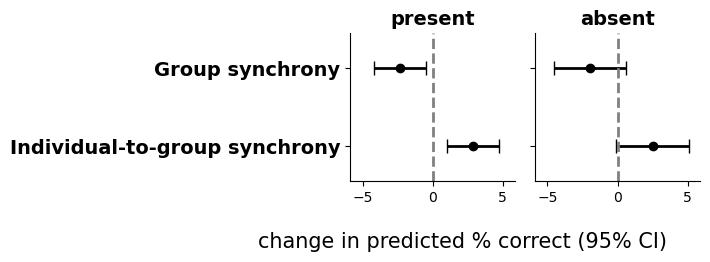

Saved: /Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_present_absent_AME_forestplot.png


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#removing trial accuracy form the table for plotting in both signal present and signal absent

present_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_present.csv"
absent_path  = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_AME_signal_absent.csv"

df_p = pd.read_csv(present_path)
df_a = pd.read_csv(absent_path)
df_p = df_p[df_p["Predictor"].isin(["group_mean_z", "pilot_mean_z"])]
df_a = df_a[df_a["Predictor"].isin(["group_mean_z", "pilot_mean_z"])]

order = ["Group synchrony", "Individual-to-group synchrony"]
df_p["label_plot"] = pd.Categorical(df_p["label_plot"], categories=order, ordered=True)
df_a["label_plot"] = pd.Categorical(df_a["label_plot"], categories=order, ordered=True)

df_p = df_p.sort_values("label_plot").reset_index(drop=True)
df_a = df_a.sort_values("label_plot").reset_index(drop=True)

df_p["AME_pp"] = df_p["AME"] *100
df_p["CI_low"] = df_p["CI_low"] *100
df_p["CI_high"] = df_p["CI_high"] *100

df_a["AME_pp"] = df_a["AME"] *100
df_a["CI_low"] = df_a["CI_low"] *100
df_a["CI_high"] = df_a["CI_high"] *100

y_pos = np.arange(len(df_p))

fig, (ax_p, ax_a) = plt.subplots(1, 2, figsize=(7.2, 2.6), sharey=True)

# present
ax_p.errorbar(
    df_p["AME_pp"], y_pos,
    xerr=[df_p["AME_pp"] - df_p["CI_low"], df_p["CI_high"] - df_p["AME_pp"]],
    fmt="o", color="black", ecolor="black", elinewidth=2, capsize=5, markersize=6
)
ax_p.axvline(0, linestyle="--", color="gray", linewidth=2)
ax_p.set_title("present", fontsize=14, weight="bold")


# absent
ax_a.errorbar(
    df_a["AME_pp"], y_pos,
    xerr=[df_a["AME_pp"] - df_a["CI_low"], df_a["CI_high"] - df_a["AME_pp"]],
    fmt="o", color="black", ecolor="black", elinewidth=2, capsize=5, markersize=6
)
ax_a.axvline(0, linestyle="--", color="gray", linewidth=2)
ax_a.set_title("absent", fontsize=14, weight="bold")

ax_p.set_ylim(len(y_pos) - 0.5, -0.5)
# title for x-axis

fig.supxlabel("change in predicted % correct (95% CI)", fontsize=15, x = 0.65)

plt.tight_layout()

# y labels
ax_p.set_yticks(y_pos)
ax_p.set_yticklabels(df_p["label_plot"].astype(str).values, fontsize=14, fontweight="bold")
ax_p.invert_yaxis()

# tighten whitespace
ax_p.margins(y=0.03)
ax_a.margins(y=0.03)
ax_p.set_ylim(len(y_pos) - 0.55, -0.45)

# symmetric x limits
xmin = min(df_p["CI_low"].min(), df_a["CI_low"].min())
xmax = max(df_p["CI_high"].max(), df_a["CI_high"].max())
m = max(abs(xmin), abs(xmax)) * 1.15
ax_p.set_xlim(-m, m)
ax_a.set_xlim(-m, m)

for ax in (ax_p, ax_a):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="x", labelsize=10)

plt.tight_layout()

out_path = "/Users/olgagulka/Desktop/IBS/eye_tracking/scripts_sync_analysis/GLMM_results_plotting/YN_present_absent_AME_forestplot.png"
plt.savefig(out_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
